<a href="https://colab.research.google.com/github/karolinesusin82-blip/Analise_NPS/blob/main/analise_nps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd

url = "https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv"

df = pd.read_csv(url)

df.head()



,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [ ]:
df.shape

(2500, 19)

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [ ]:
df = df.replace('-', np.nan)

df['nps_score'] = pd.to_numeric(df['nps_score'], errors='coerce')

df = df.dropna(subset=['nps_score'])

In [ ]:
def classificar(score):
    if score < 7:
        return 'Detrator'
    elif score < 9:
        return 'Neutro'
    else:
        return 'Promotor'

df['nps_class'] = df['nps_score'].apply(classificar)

df['nps_class'].value_counts(normalize=True) * 100


,proportion
nps_class,
Detrator,84.36
Neutro,11.24
Promotor,4.40


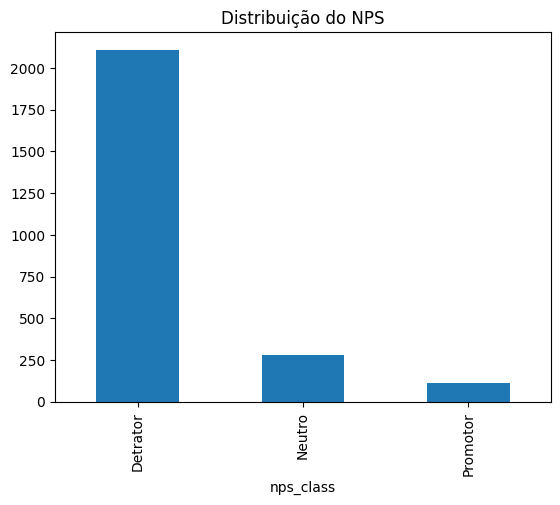

In [ ]:
import matplotlib.pyplot as plt
df['nps_class'].value_counts().plot(kind='bar')
plt.title('Distribuição do NPS')
plt.show()

In [ ]:
df['atraso'] = df['delivery_delay_days'] > 0

pd.crosstab(df['nps_class'], df['atraso'], normalize='index') * 100

atraso,False,True
nps_class,,
Detrator,6.780465,93.219535
Neutro,29.893238,70.106762
Promotor,45.454545,54.545455


In [ ]:
df.groupby('nps_class')['delivery_delay_days'].mean()

,delivery_delay_days
nps_class,
Detrator,2.414889
Neutro,1.053381
Promotor,0.718182


In [ ]:
df.groupby('nps_class')['customer_service_contacts'].mean()

,customer_service_contacts
nps_class,
Detrator,1.632053
Neutro,1.007117
Promotor,0.672727


In [ ]:
df.groupby('nps_class')['delivery_time_days'].mean()

,delivery_time_days
nps_class,
Detrator,7.994310
Neutro,8.263345
Promotor,7.936364


In [ ]:
pd.crosstab(df['customer_region'], df['nps_class'], normalize='index') * 100

nps_class,Detrator,Neutro,Promotor
customer_region,,,
Centro-Oeste,84.188034,10.470085,5.341880
Nordeste,85.567010,10.103093,4.329897
Norte,85.177866,11.264822,3.557312
Sudeste,83.653846,11.923077,4.423077
Sul,83.301344,12.284069,4.414587


** Conclusões**

- O atraso na entrega é o principal fator de insatisfação
- Clientes que entram mais em contato com atendimento tendem a ser detratores
- O tempo de entrega impacta diretamente a experiência
- O problema não parece estar concentrado em uma região específica

**Resumo**

O problema não está na venda, mas na experiência após a compra, principalmente na entrega.
